## Ucitavanje podataka

In [1]:
import os
import glob 
import numpy as np 
import pandas as pd

from sklearn.model_selection import train_test_split

In [2]:
RAW_DATA_PATH = "../../data/raw"
PROCESSED_DATA_PATH = "../../data/processed"

In [3]:
csv_files = glob.glob(os.path.join(RAW_DATA_PATH, "*.csv"))
print(f"Total files found: {len(csv_files)}")

Total files found: 153


In [4]:
X_list = []
y_list = []

font_list = []
strength_list = []
italic_list = []

total_rows = 0

for i, file in enumerate(csv_files):
    print(f"Loading file {i+1}/{len(csv_files)}: {file}")

    df = pd.read_csv(file)
    pixel_columns = [col for col in df.columns if col.startswith("r")]

    X_batch = df[pixel_columns].values.astype(np.uint8)
    y_batch = df["m_label"].values.astype(np.uint8)

    font_batch = df["font"].values
    strength_batch = df["strength"].values.astype(np.float32)
    italic_batch = df["italic"].values.astype(np.uint8)

    X_list.append(X_batch)
    y_list.append(y_batch)

    font_list.append(font_batch)
    strength_list.append(strength_batch)
    italic_list.append(italic_batch)

    total_rows += X_batch.shape[0]

    del df
total_rows


Loading file 1/153: ../../data/raw/BODONI.csv
Loading file 2/153: ../../data/raw/PHAGSPA.csv
Loading file 3/153: ../../data/raw/GARAMOND.csv
Loading file 4/153: ../../data/raw/SANSSERIF.csv
Loading file 5/153: ../../data/raw/LEELAWADEE.csv
Loading file 6/153: ../../data/raw/FORTE.csv
Loading file 7/153: ../../data/raw/PALACE.csv
Loading file 8/153: ../../data/raw/MODERN.csv
Loading file 9/153: ../../data/raw/IMPACT.csv
Loading file 10/153: ../../data/raw/COURIER.csv
Loading file 11/153: ../../data/raw/CAARD.csv
Loading file 12/153: ../../data/raw/MONOTYPE.csv
Loading file 13/153: ../../data/raw/NINA.csv
Loading file 14/153: ../../data/raw/CASTELLAR.csv
Loading file 15/153: ../../data/raw/CALIBRI.csv
Loading file 16/153: ../../data/raw/CALISTO.csv
Loading file 17/153: ../../data/raw/ISOC.csv
Loading file 18/153: ../../data/raw/ITALIC.csv
Loading file 19/153: ../../data/raw/BLACKADDER.csv
Loading file 20/153: ../../data/raw/JUICE.csv
Loading file 21/153: ../../data/raw/VLADIMIR.csv
Loadi

832670

In [5]:
X = np.vstack(X_list)
y = np.concatenate(y_list)

font = np.concatenate(font_list)
strength = np.concatenate(strength_list)
italic = np.concatenate(italic_list)

print("Final X shape: ", X.shape)
print("Final y shape: ", y.shape)
print("Final font shape: ", font.shape)
print("Final strength shape: ", strength.shape)
print("Final italic shape: ", italic.shape)

print("\ncheck the same number of samples:")
print("X vs y: ", X.shape[0] == y.shape[0])
print("X vs font: ", X.shape[0] == font.shape[0])
print("X vs strength: ", X.shape[0] == strength.shape[0])
print("X vs italic: ", X.shape[0] == italic.shape[0])

del X_list
del y_list
del font_list
del strength_list
del italic_list

Final X shape:  (832670, 400)
Final y shape:  (832670,)
Final font shape:  (832670,)
Final strength shape:  (832670,)
Final italic shape:  (832670,)

check the same number of samples:
X vs y:  True
X vs font:  True
X vs strength:  True
X vs italic:  True


## Validacija podataka

In [6]:
print("Minimal pixel value: ", X.min())
print("Maximal pixel value: ", X.max())

print("Does X contain any NaN: ", np.isnan(X).any())
print("Does y contain any NaN: ", np.isnan(y).any())
print("Does strength contain any NaN: ", np.isnan(strength).any())

print("\nUnique y classes: ", len(np.unique(y)))
print("Unique fonts: ", len(np.unique(font)))
print("Italic values: ", np.unique(italic))

Minimal pixel value:  0
Maximal pixel value:  255
Does X contain any NaN:  False
Does y contain any NaN:  False
Does strength contain any NaN:  False

Unique y classes:  256
Unique fonts:  153
Italic values:  [0 1]


### Balansiranost klasa

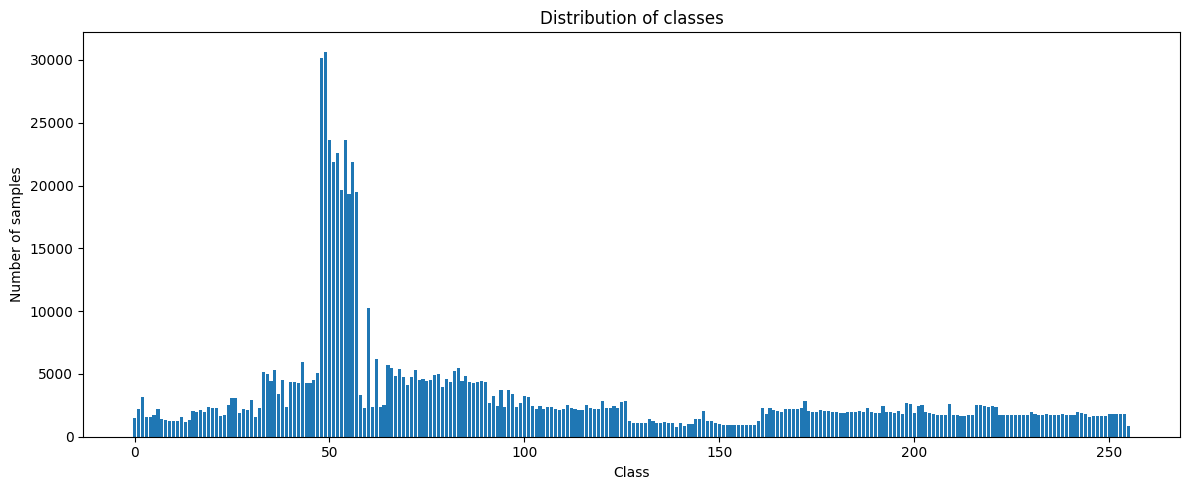

In [7]:
import matplotlib.pyplot as plt
import numpy as np

unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(12,5))
plt.bar(unique, counts)

plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Distribution of classes")

plt.tight_layout()
plt.show()

Provera m_label kolone u originalnim podacima

In [12]:
print("===== Character label info =====")
print("Broj klasa:", len(np.unique(y)))
print("Min label:", y.min())
print("Max label:", y.max())

print("\n===== Font info =====")
print("Broj fontova:", len(np.unique(font)))

print("\n===== Italic info =====")
print("Unique italic values:", np.unique(italic))

print("\n===== Strength info =====")
print("Min strength:", strength.min())
print("Max strength:", strength.max())

===== Character label info =====
Broj klasa: 256
Min label: 0
Max label: 255

===== Font info =====
Broj fontova: 153

===== Italic info =====
Unique italic values: [0 1]

===== Strength info =====
Min strength: 0.4
Max strength: 0.7


### Konverzija podataka uint8 -> float32 za rad sa modelima

In [13]:
X = X.astype(np.float32)
print(X.dtype)

float32


### Stratified train-test split 

In [14]:
X_train, X_test, \
y_train, y_test, \
font_train, font_test, \
strength_train, strength_test, \
italic_train, italic_test = train_test_split(
    X,
    y,
    font,
    strength,
    italic,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("X Train shape: ", X_train.shape)
print("X Test shape: ", X_test.shape)

print("y Train shape: ", y_train.shape)
print("y Test shape: ", y_test.shape)

print("Font Train shape: ", font_train.shape)
print("Strength Train shape: ", strength_train.shape)
print("Italic Train shape: ", italic_train.shape)


X Train shape:  (666136, 400)
X Test shape:  (166534, 400)
y Train shape:  (666136,)
y Test shape:  (166534,)
Font Train shape:  (666136,)
Strength Train shape:  (666136,)
Italic Train shape:  (666136,)


### Cuvanje preprocessed dataset-a

In [ ]:
output_path = os.path.join(PROCESSED_DATA_PATH, "preprocessed.npz")

np.savez_compressed(
    output_path,
    X_train = X_train,
    X_test = X_test,
    y_train = y_train,
    y_test = y_test,
    font_train = font_train,
    strength_train = strength_train,
    strength_test = strength_test,
    italic_train = italic_train,
    italic_test = italic_test
)

print(f"Dataset successfully saved in: {output_path}")

Dataset successfully saved in: ../data/processed/preprocessed.npz
